In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/text-classificationboth/train.csv
/kaggle/input/text-classificationboth/test.csv
/kaggle/input/glove-100d/glove.6B.100d.txt


In [2]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 6.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 7.5 MB/s eta 0:00:00


In [3]:
import os
import re
import string
import random as rnd

# Data analysis and wrangling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import resample

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
import nltk
nltk.download('wordnet', download_dir='/root/nltk_data')
import nltk
import subprocess

# Define the download directory
download_dir = '/kaggle/working/nltk_data'

# Download the WordNet corpus
nltk.download('wordnet', download_dir=download_dir)

# Unzip the downloaded corpus
unzip_command = f"unzip {download_dir}/corpora/wordnet.zip -d {download_dir}/corpora"
subprocess.run(unzip_command, shell=True)

# Append the download directory to NLTK's data path
nltk.data.path.append(download_dir)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data...


In [5]:
from tensorflow.keras.mixed_precision import set_global_policy

# Enable mixed precision for improved performance on compatible hardware (GPU)
set_global_policy('mixed_float16')

In [6]:
# Load dataset
train_df = pd.read_csv("/kaggle/input/text-classificationboth/train.csv")
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
lemmatizer = WordNetLemmatizer()
# Add negation words to the stopwords list
custom_stopwords = set(stopwords.words('english')) - {'not', "n't", 'no'}

# Text preprocessing
def process_comment(comment):
    comment = comment.lower()
    comment = re.sub(r'http\S+|www\S+|https\S+', '', comment)  # Remove URLs
    comment = re.sub(r'[^a-zA-Z\s]', '', comment)  # Remove special characters
    comment = re.sub(r'#\w+', '', comment)  # Remove hashtags
    comment = re.sub(r'@\w+', '', comment)  # Remove mentions
    comment = contractions.fix(comment)
    comment = comment.replace('\n', ' ').replace('\r', ' ')  # Remove newline characters
    comment = re.sub(r'\s+', ' ', comment).strip()  # Remove extra spaces
    tokens = word_tokenize(comment)
    clean_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in custom_stopwords]
    return ' '.join(clean_tokens)

train_df['cleaned_comments'] = train_df['comment_text'].apply(process_comment)

In [7]:
# Before balancing - print class distribution in the original dataset
print("Original class distribution:")
print(train_df[labels].sum(axis=0))

# Handling class imbalance using random under-sampling and over-sampling
majority_class = train_df[train_df[labels].sum(axis=1) == 0]
minority_classes = {}
for label in labels:
    minority_classes[label] = train_df[train_df[label] == 1]

# Under-sample the majority class
under_sampled_majority = resample(majority_class, replace=False, n_samples=int(len(majority_class) * 0.5), random_state=42)

# Print the number of samples in the majority class before and after undersampling
print(f"\nMajority class - before under-sampling: {len(majority_class)}")
print(f"Majority class - after under-sampling: {len(under_sampled_majority)}")

# Over-sample minority classes
resampled_classes = []
for label, data in minority_classes.items():
    oversampled = resample(data, replace=True, n_samples=len(under_sampled_majority), random_state=42)
    resampled_classes.append(oversampled)

    # Print the number of samples in each minority class before and after oversampling
    print(f"\nMinority class '{label}' - before over-sampling: {len(data)}")
    print(f"Minority class '{label}' - after over-sampling: {len(oversampled)}")


balanced_df = pd.concat([under_sampled_majority] + resampled_classes).sample(frac=1, random_state=42)

# After balancing - print class distribution in the new balanced dataset
print("\nClass distribution after balancing:")
print(balanced_df[labels].sum(axis=0))

Original class distribution:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

Majority class - before under-sampling: 143346
Majority class - after under-sampling: 71673

Minority class 'toxic' - before over-sampling: 15294
Minority class 'toxic' - after over-sampling: 71673

Minority class 'severe_toxic' - before over-sampling: 1595
Minority class 'severe_toxic' - after over-sampling: 71673

Minority class 'obscene' - before over-sampling: 8449
Minority class 'obscene' - after over-sampling: 71673

Minority class 'threat' - before over-sampling: 478
Minority class 'threat' - after over-sampling: 71673

Minority class 'insult' - before over-sampling: 7877
Minority class 'insult' - after over-sampling: 71673

Minority class 'identity_hate' - before over-sampling: 1405
Minority class 'identity_hate' - after over-sampling: 71673

Class distribution after balancing:
toxic            41115

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['cleaned_comments'], balanced_df[labels], test_size=0.2, random_state=42
)

# Tokenization and padding
max_words = 50000
max_length = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [9]:
# Load GloVe embeddings
embedding_dim = 100
glove_path = "/kaggle/input/glove-100d/glove.6B.100d.txt"
embeddings_index = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [10]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class Attention(Layer):
    def __init__(self, **kwargs):
        # Initialize the Attention layer
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        # Create a trainable weight variable for the attention mechanism
        self.attention_weight = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Compute scores using the attention weight and input features
        scores = K.tanh(K.dot(x, self.attention_weight))         
        # Normalize scores to probabilities using softmax
        attention_weights = K.softmax(scores, axis=1)         
        # Compute the context vector as a weighted sum of input features
        context_vector = K.sum(x * attention_weights, axis=1)         
        return context_vector
      

# Model architecture
input_layer = Input(shape=(max_length,))  # Input layer for sequences with a maximum length of 'max_length'

embedding_layer = Embedding(
    input_dim=max_words,  # Vocabulary size
    output_dim=embedding_dim,  # Dimension of embedding vectors
    weights=[embedding_matrix],  # Pre-trained embedding weights
    input_length=max_length,  # Length of input sequences
    trainable=True  # Allow fine-tuning of embeddings
)(input_layer)

# Standard LSTM layer for sequential modeling
lstm_output = LSTM(128, return_sequences=True)(embedding_layer)

# Attention layer for focusing on important features in the LSTM output
attention_output = Attention()(lstm_output)

# Reshape the attention layer output to be compatible with Conv1D input requirements
reshaped_attention_output = layers.Reshape(
    (1, attention_output.shape[-1])  # Shape: (batch_size, 1, feature_dim)
)(attention_output)

# 1D Convolutional layer applied after the LSTM and Attention mechanism
conv1d_output = Conv1D(
    filters=64,  
    kernel_size=1,  
    activation='relu'  # ReLU activation function
)(reshaped_attention_output)

# Flatten the Conv1D output for fully connected layers
flattened_output = Flatten()(conv1d_output)

# Dense (fully connected) layer for learning high-level representations
fc_layer = Dense(128, activation='relu')(flattened_output)

# Dropout layer to prevent overfitting during training
regularization_layer = Dropout(0.5)(fc_layer)

# Output layer with sigmoid activation for multi-label classification
output_layer = Dense(
    len(labels),
    activation='sigmoid'  # Sigmoid activation for independent probability predictions
)(regularization_layer)

# Defining the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model with appropriate optimizer, loss function, and evaluation metrics
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]  # Accuracy and AUC metrics
)

# Print Model Summary
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 100, 100)            │       5,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100, 128)            │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention (Attention)                │ (None, 128)                 │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 1, 64)               │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,134,726 (19.59 MB)

 Trainable params: 5,134,726 (19.59 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
# Training
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 87s 13ms/step - accuracy: 0.8928 - auc: 0.9621 - loss: 0.2250 - val_accuracy: 0.9500 - val_auc: 0.9985 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 2/20
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.9397 - auc: 0.9988 - loss: 0.0339 - val_accuracy: 0.9811 - val_auc: 0.9994 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 3/20
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.9707 - auc: 0.9995 - loss: 0.0177 - val_accuracy: 0.9913 - val_auc: 0.9993 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 4/20
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - accuracy: 0.9809 - auc: 0.9996 - loss: 0.0129 - val_accuracy: 0.9941 - val_auc: 0.9992 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 5/20
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - accuracy: 0.9873 - auc: 0.9997 - loss: 0.0114 - val_accuracy: 0.9891 - val_auc: 0.9993 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 6/20
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 79s 13ms/step - ac

In [12]:
# Evaluate
loss, accuracy, auc = model.evaluate(X_test_pad, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}, Test AUC: {auc:.4f}")

# Classification report
y_pred = model.predict(X_test_pad)
y_pred_binary = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred_binary, target_names=labels))

3136/3136 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9961 - auc: 0.9993 - loss: 0.0149
Test Loss: 0.0150, Test Accuracy: 0.9961, Test AUC: 0.9993
3136/3136 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
               precision    recall  f1-score   support

        toxic       0.99      1.00      1.00     82460
 severe_toxic       0.99      1.00      0.99     27557
      obscene       1.00      1.00      1.00     66741
       threat       1.00      1.00      1.00     17777
       insult       1.00      1.00      1.00     65394
identity_hate       1.00      1.00      1.00     25287

    micro avg       1.00      1.00      1.00    285216
    macro avg       0.99      1.00      1.00    285216
 weighted avg       1.00      1.00      1.00    285216
  samples avg       0.85      0.86      0.85    285216



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


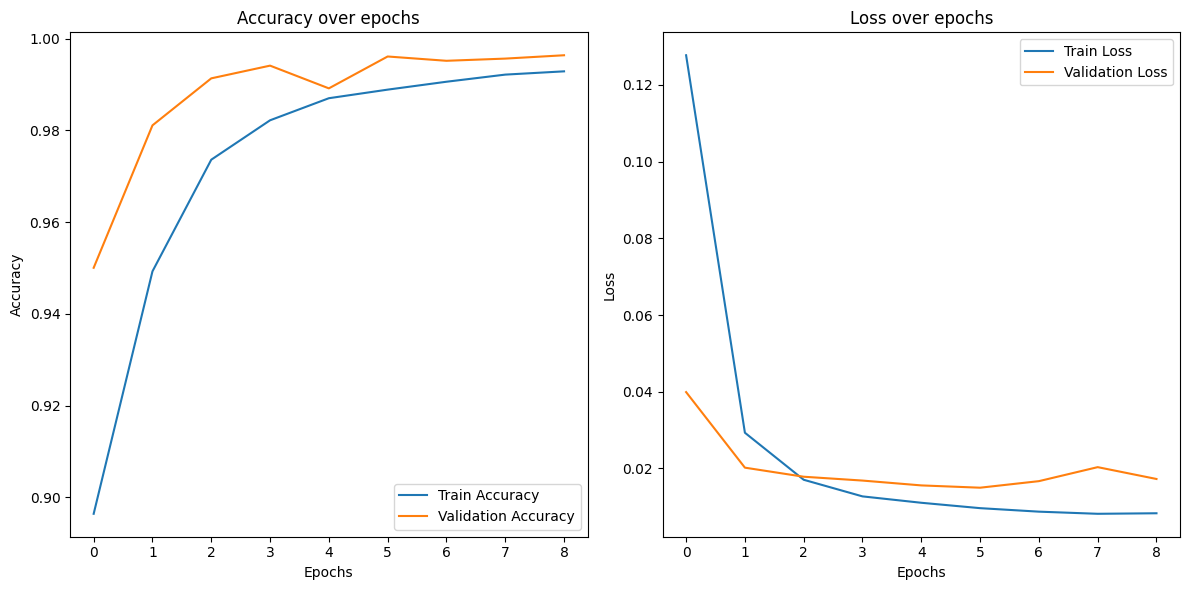

In [13]:
import matplotlib.pyplot as plt
# Plot accuracy and loss for training and validation
def plot_accuracy_loss(history):
    # Plot Accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call function to plot
plot_accuracy_loss(history)

Confusion Matrix for toxic:
 [[17450   433]
 [  220 82240]]


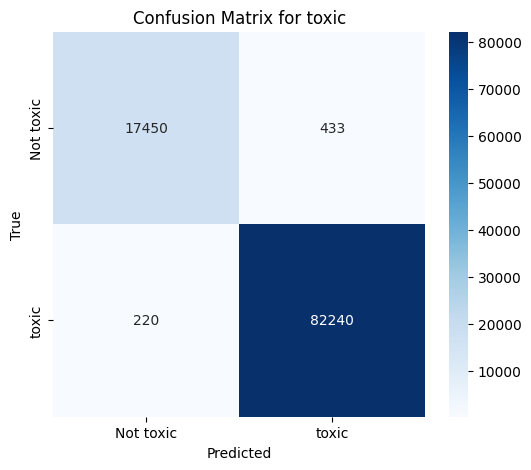

Confusion Matrix for severe_toxic:
 [[72433   353]
 [   95 27462]]


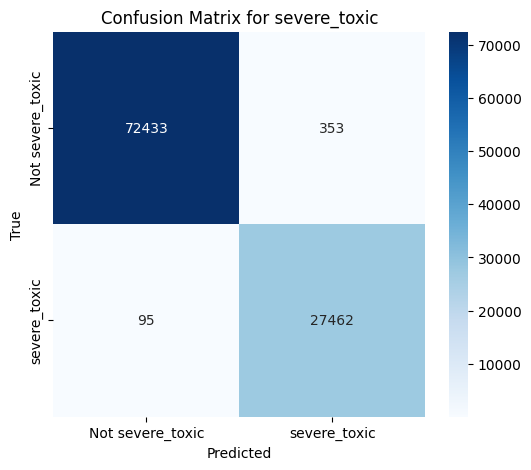

Confusion Matrix for obscene:
 [[33471   131]
 [  191 66550]]


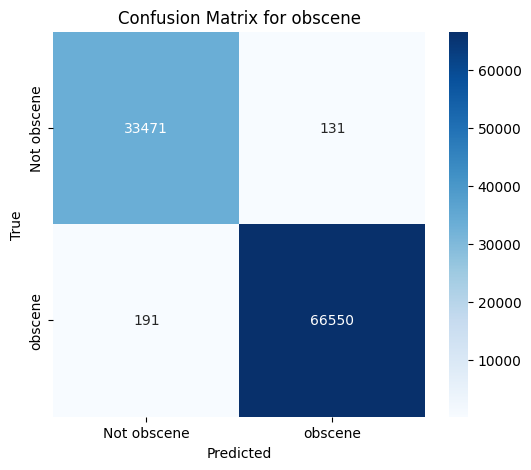

Confusion Matrix for threat:
 [[82498    68]
 [    0 17777]]


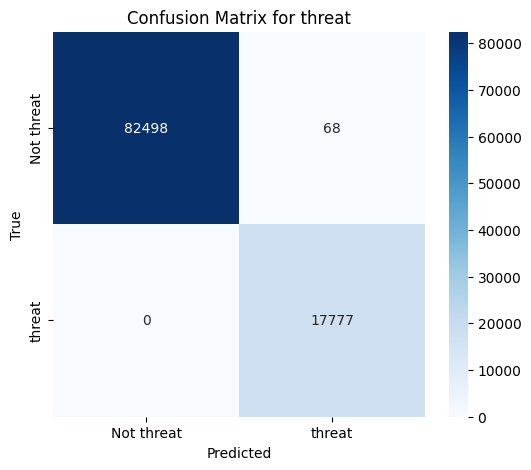

Confusion Matrix for insult:
 [[34639   310]
 [  143 65251]]


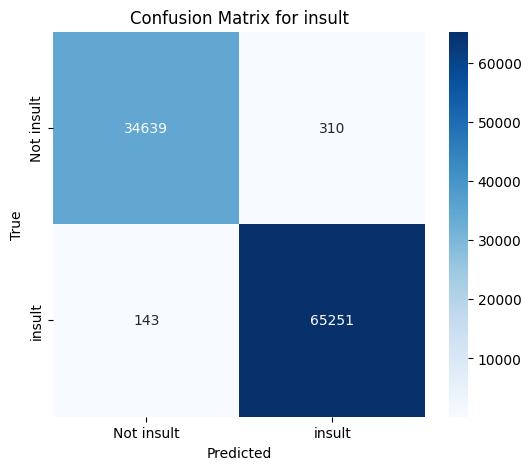

Confusion Matrix for identity_hate:
 [[74984    72]
 [   56 25231]]


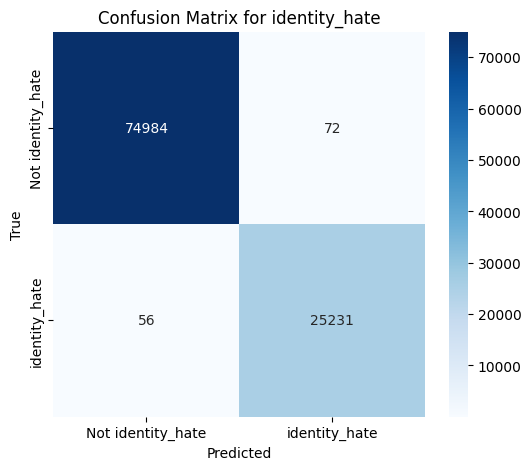

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Confusion Matrix for each label
def plot_confusion_matrix(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion Matrix for {label}:\n", cm)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[f'Not {label}', f'{label}'], yticklabels=[f'Not {label}', f'{label}'])
    plt.title(f"Confusion Matrix for {label}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
# Plot confusion matrix for each label
for label in labels:
    plot_confusion_matrix(y_test[label].values, y_pred_binary[:, labels.index(label)], label)

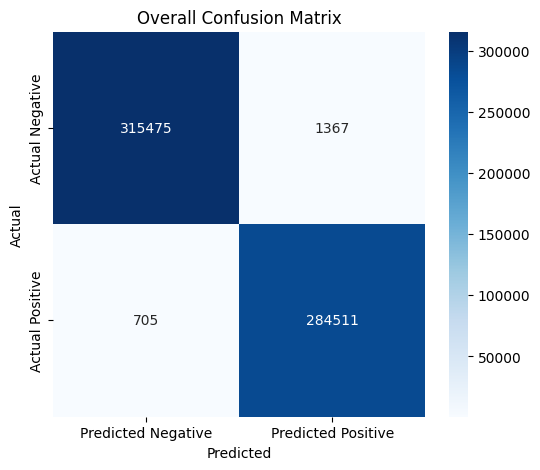

Accuracy: 0.9965584711107568


In [15]:
# Combine all true and predicted labels
y_true_flat = y_test[labels].values.flatten()
y_pred_flat = y_pred_binary.flatten()
# Compute confusion matrix
cm_overall = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_overall, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Negative", "Predicted Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Overall Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Calculate accuracy
accuracy = np.sum(np.diag(cm_overall)) / np.sum(cm_overall)
print(f"Accuracy: {accuracy}")

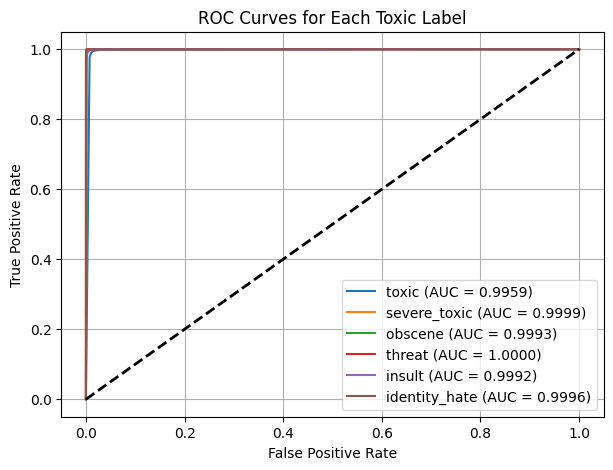

In [16]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for each label
plt.figure(figsize=(7,5))
for i, label in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_test[label], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curves for Each Toxic Label')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [17]:
from sklearn.metrics import classification_report, roc_auc_score
# Compute ROC-AUC for each label
roc_auc = roc_auc_score(y_test, y_pred, average=None)
print("ROC-AUC scores for each label:", dict(zip(labels, roc_auc)))

ROC-AUC scores for each label: {'toxic': 0.9959167987233265, 'severe_toxic': 0.9999037085025628, 'obscene': 0.9993486300481053, 'threat': 0.9999687097984834, 'insult': 0.99923482629414, 'identity_hate': 0.9996033723011185}
